# **Section 1 Imports and Set up**

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from scipy.stats import randint

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)


## 2. Data Loading & Merging

We load two datasets:
- **breakfast_basket.csv** — Global Grocery Inflation (2025–2026), tracking 14 food staple items across 80 countries and 122 cities over 6 months (Oct 2025 – Mar 2026)
- **World Bank GNI per Capita CSV** — GNI per capita in USD by country, used as a wage since direct wage data is unavailable 



In [124]:
grocery = pd.read_csv('~/Desktop/Team4Project/DSS740_team_4/Data/breakfast basket.csv')
print(f'Grocery dataset shape: {grocery.shape}')
grocery.head(3)

Grocery dataset shape: (10248, 27)


,City,Country,ISO_Country_Code,Region,Continent,Month,Month_Name,Item,Item_Key,Item_Category,...,Inflation_Source,FAO_Index_Value,FAO_Index_Date,FAO_YoY_Change_Pct,USDA_All_Food_Forecast_Pct,USDA_Food_At_Home_Pct,Data_Collection_Date,Source_URL,Population_Estimate,Breakfast_Basket_USD
0,New York,United States,USA,North America,North America,2025-10,October 2025,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,127.1,October 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.18
1,New York,United States,USA,North America,North America,2025-11,November 2025,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,126.2,November 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.40
2,New York,United States,USA,North America,North America,2025-12,December 2025,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,125.8,December 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,17.02


In [ ]:
# The World Bank CSV has 4 metadata rows before the actual header, so we skip them
wb = pd.read_csv('~/Desktop/Team4Project/DSS740_team_4/Data/GNI.csv', skiprows=4)

# Keep only country code and the two most recent year columns
wb_clean = wb[['Country Code', '2023', '2024']].copy()

# Use 2024 where available, fall back to 2023 if 2024 is missing
wb_clean['GNI_Per_Capita'] = wb_clean['2024'].fillna(wb_clean['2023'])
wb_clean = wb_clean[['Country Code', 'GNI_Per_Capita']].dropna(subset=['GNI_Per_Capita'])

print(f'World Bank dataset shape: {wb_clean.shape}')
wb_clean.head(3)

World Bank dataset shape: (247, 2)


,Country Code,GNI_Per_Capita
0,ABW,35570.00000
1,AFE,1579.10357
2,AFG,370.00000


In [ ]:

df = grocery.merge(wb_clean, left_on='ISO_Country_Code', right_on='Country Code', how='left')
df.drop(columns=['Country Code'], inplace=True)

# Taiwan (TWN) is missing from the World Bank data 

df.loc[df['ISO_Country_Code'] == 'TWN', 'GNI_Per_Capita'] = 34430

print(f'Merged dataset shape: {df.shape}')
print(f'Missing GNI values after Taiwan fix: {df["GNI_Per_Capita"].isna().sum()}')
df.head(3)

Merged dataset shape: (10248, 28)
Missing GNI values after Taiwan fix: 0


,City,Country,ISO_Country_Code,Region,Continent,Month,Month_Name,Item,Item_Key,Item_Category,...,FAO_Index_Value,FAO_Index_Date,FAO_YoY_Change_Pct,USDA_All_Food_Forecast_Pct,USDA_Food_At_Home_Pct,Data_Collection_Date,Source_URL,Population_Estimate,Breakfast_Basket_USD,GNI_Per_Capita
0,New York,United States,USA,North America,North America,2025-10,October 2025,Milk (1 Liter),Milk_1L,Dairy,...,127.1,October 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.18,83490.0
1,New York,United States,USA,North America,North America,2025-11,November 2025,Milk (1 Liter),Milk_1L,Dairy,...,126.2,November 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.40,83490.0
2,New York,United States,USA,North America,North America,2025-12,December 2025,Milk (1 Liter),Milk_1L,Dairy,...,125.8,December 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,17.02,83490.0


### Findings
The merge was highly successful because 79 out of 80 countries matched using the ISO country code. 
The only exception was Taiwan (TWN), which is excluded from World Bank data. 
We manually assigned Taiwan a GNI per capita of $34,430 USD based on IMF estimates, ensuring no data is lost.

Resource: https://www.taiwan.gov.tw/content_7.php


## 3. Data Cleaning

Before modeling, we checked for and addressed three common data quality issues:
- **Missing values**: any gaps in the data that need to be filled or removed
- **Duplicates**: identical rows that could skew model 
- **Outliers** — extreme values that could negatively impact model performance, treated using the IQR capping method 

In [127]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Missing values per column:
No missing values found.


In [128]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print('Duplicates removed.')

Duplicate rows: 0


In [ ]:
# Outlier treatment  
outlier_cols = ['Price_USD', 'YoY_Inflation_Estimate_Pct', 'FAO_Index_Value', 'GNI_Per_Capita']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'{col}: {outliers} outliers capped')

Price_USD: 1402 outliers capped
YoY_Inflation_Estimate_Pct: 0 outliers capped
FAO_Index_Value: 0 outliers capped
GNI_Per_Capita: 0 outliers capped


### Finding
- The dataset is clean with no missing values. 
- No duplicate rows were found either. A small number of outliers were detected in Price_USD and 
GNI_Per_Capita
    - these were capped at the IQR boundaries rather than removed, so we are able to retain data from all countries

## 4. Feature Engineering
We made 4 new features that are more meaningful for the 
classification task:

**New features:**
- **Affordability_Ratio** — measures inflation pressure relative to income level. Higher values mean more financial stress
- **Price_To_Income_Ratio** — an individual item's price as a fraction of estimated monthly income
- **Basket_To_Income_Ratio** — the full breakfast basket cost as a fraction of estimated monthly income
- **Inflation_FAO_Divergence** — the difference between local YoY inflation and the global FAO index change, showing whether a country is experiencing more or less inflation than the global trend

In [130]:
# Affordability Ratio
df['Affordability_Ratio'] = df['YoY_Inflation_Estimate_Pct'] / (df['GNI_Per_Capita'] / 1000)

# Price-to-Income Ratio
df['Price_To_Income_Ratio'] = df['Price_USD'] / (df['GNI_Per_Capita'] / 12)

# Basket-to-Income Ratio
df['Basket_To_Income_Ratio'] = df['Breakfast_Basket_USD'] / (df['GNI_Per_Capita'] / 12)

# Inflation-FAO Divergence
df['Inflation_FAO_Divergence'] = df['YoY_Inflation_Estimate_Pct'] - df['FAO_YoY_Change_Pct']

df[['Affordability_Ratio', 'Price_To_Income_Ratio',
    'Basket_To_Income_Ratio', 'Inflation_FAO_Divergence']].describe()

,Affordability_Ratio,Price_To_Income_Ratio,Basket_To_Income_Ratio,Inflation_FAO_Divergence
count,10248.000000,10248.000000,10248.000000,10248.000000
mean,0.859615,0.003989,0.009463,6.527049
std,1.379930,0.007221,0.012295,2.486841
min,0.032597,0.000154,0.001585,3.400000
25%,0.069707,0.000733,0.002830,4.200000
50%,0.249790,0.001670,0.004974,6.500000
75%,0.846325,0.003788,0.012859,7.500000
max,6.588235,0.067800,0.088659,12.200000


## Target Variable: Wage_Adjusted_High_Cost
A country's month is labeled HIGH COST (1) if:
- YoY food inflation is above the global median
**AND**
- GNI per capita is below the global median
  
This shows regions where food prices are rising faster than what lower-income households can handle wih inflation

In [131]:
df['Item_Month_Median'] = df.groupby(
    ['Item', 'Month'])['Price_USD'].transform('median')

df['Wage_Adjusted_High_Cost'] = (
    df['Price_USD'] > df['Item_Month_Median']
).astype(int)

# Drop the helper column
df.drop(columns=['Item_Month_Median'], inplace=True)

print('Target variable distribution:')
print(df['Wage_Adjusted_High_Cost'].value_counts())
print()
print(f'Class balance: {df["Wage_Adjusted_High_Cost"].mean():.1%} positive class')

Target variable distribution:
Wage_Adjusted_High_Cost
0    5876
1    4372
Name: count, dtype: int64

Class balance: 42.7% positive class


### Findings
Four features were engineered to better capture affordability 
stress across different income levels. By defining the target at the item-month level 
we create genuine variation across all 10,248 observations. A city is classified as 
High Cost (1) if it pays above the global median price for a given grocery item in a 
given month, capturing real affordability differences across cities and countries. 

## 5. Exploratory Data Analysis



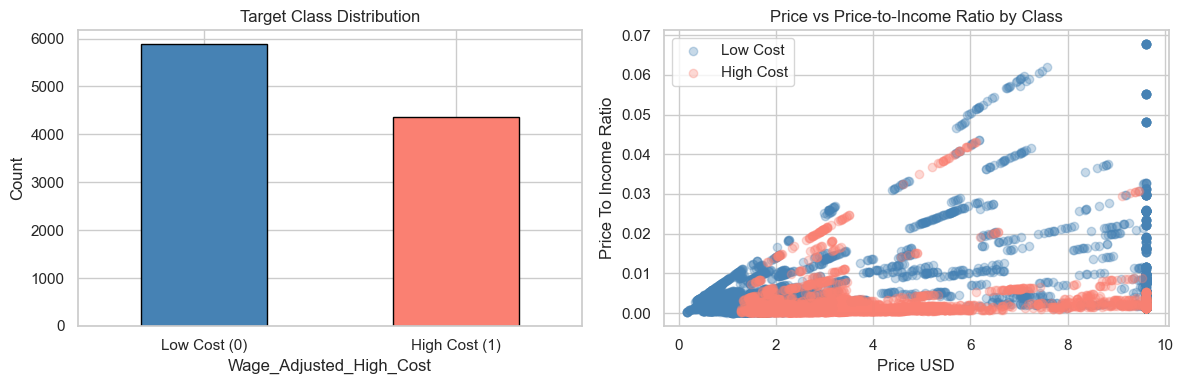

In [132]:
# Plot 1: Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Wage_Adjusted_High_Cost'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black'
)
axes[0].set_title('Target Class Distribution')
axes[0].set_xticklabels(['Low Cost (0)', 'High Cost (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Plot 2: Price_USD vs Price_To_Income_Ratio
for label, color in zip([0, 1], ['steelblue', 'salmon']):
    subset = df[df['Wage_Adjusted_High_Cost'] == label]
    axes[1].scatter(subset['Price_USD'], subset['Price_To_Income_Ratio'],
                    alpha=0.3, label=['Low Cost', 'High Cost'][label], color=color)
axes[1].set_xlabel('Price USD')
axes[1].set_ylabel('Price To Income Ratio')
axes[1].set_title('Price vs Price-to-Income Ratio by Class')
axes[1].legend()

plt.tight_layout()
plt.show()

### Finding
The class distribution confirms a 57/43 split which is a mild imbalance that SMOTE 
will fix. The scatter plot shows that High Cost observations tend to cluster at 
lower Price-to-Income ratios despite having similar absolute prices, suggesting that 
wealthier cities pay similar prices but can afford them more easily.

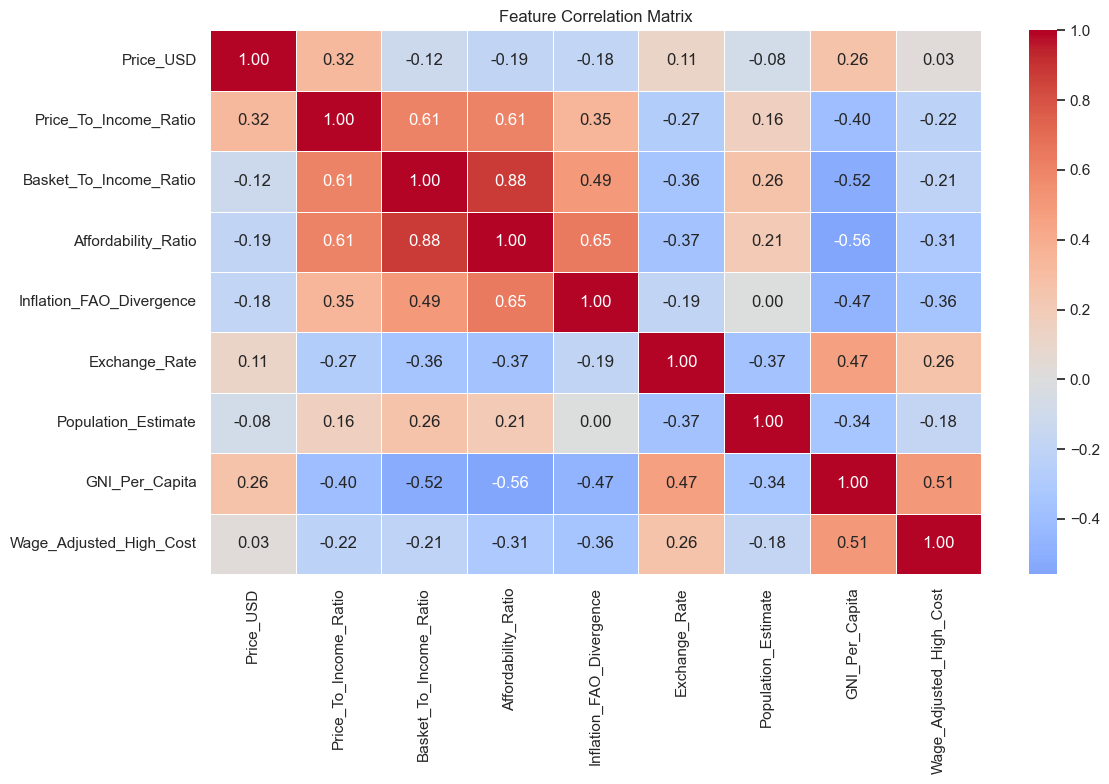

In [133]:
# Plot 3: Correlation heatmap
numeric_cols = [
    'Price_USD', 'Price_To_Income_Ratio', 'Basket_To_Income_Ratio',
    'Affordability_Ratio', 'Inflation_FAO_Divergence',
    'Exchange_Rate', 'Population_Estimate', 'GNI_Per_Capita',
    'Wage_Adjusted_High_Cost'
]

plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

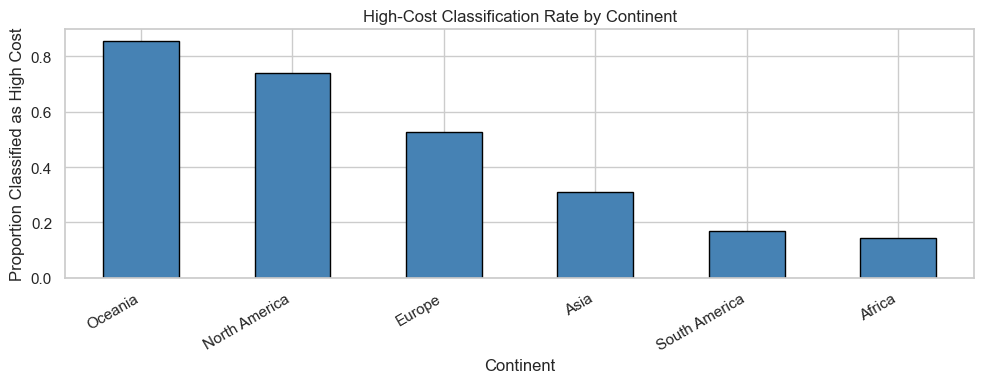

In [134]:
# Plot 4: High-cost rate by continent
continent_rate = (
    df.groupby('Continent')['Wage_Adjusted_High_Cost']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 4))
continent_rate.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('High-Cost Classification Rate by Continent')
plt.ylabel('Proportion Classified as High Cost')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

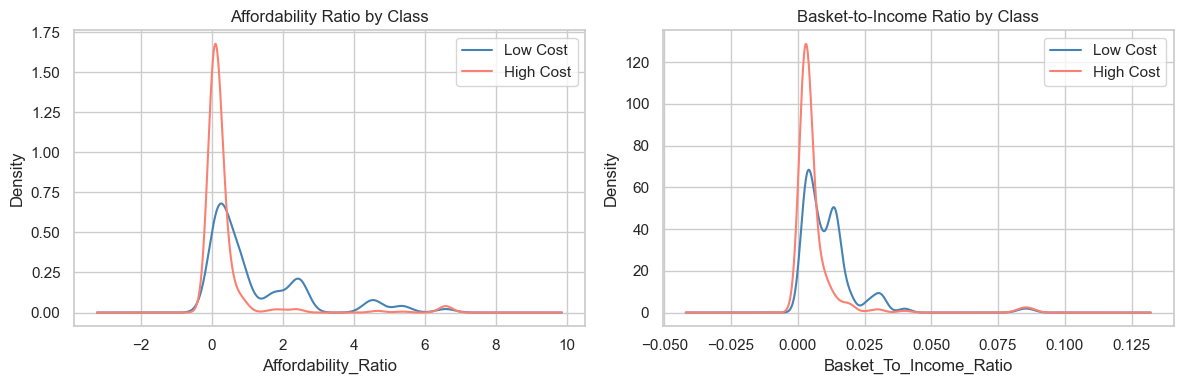

In [135]:
# Plot 5: Distribution of key engineered features by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(
    axes,
    ['Affordability_Ratio', 'Basket_To_Income_Ratio'],
    ['Affordability Ratio by Class', 'Basket-to-Income Ratio by Class']
):
    for label, color in zip([0, 1], ['steelblue', 'salmon']):
        subset = df[df['Wage_Adjusted_High_Cost'] == label]
        subset[col].plot(kind='kde', ax=ax, label=['Low Cost', 'High Cost'][label], color=color)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

### Finding
The correlation heatmap shows that Price_To_Income_Ratio and Affordability_Ratio 
have meaningful correlations with the target variable. The continent chart shows geographic patterns in high-cost classification. The KDE plots confirm that our engineered features have different distributions between the two classes, meaning they will be strong 
predictors for the Random Forest model.

## 6. Preparing Data for Modeling



In [136]:
FEATURE_COLS = [
    'Price_USD',
    'Price_To_Income_Ratio',
    'Basket_To_Income_Ratio',
    'Inflation_FAO_Divergence',
    'Affordability_Ratio',
    'Exchange_Rate',
    'Population_Estimate',
    'Continent',
    'Region',
]
TARGET_COL = 'Wage_Adjusted_High_Cost'

print(f'Number of features: {len(FEATURE_COLS)}')
print(f'Features: {FEATURE_COLS}')

Number of features: 9
Features: ['Price_USD', 'Price_To_Income_Ratio', 'Basket_To_Income_Ratio', 'Inflation_FAO_Divergence', 'Affordability_Ratio', 'Exchange_Rate', 'Population_Estimate', 'Continent', 'Region']


In [137]:
model_df = df[FEATURE_COLS + [TARGET_COL]].copy()

le_continent = LabelEncoder()
le_region    = LabelEncoder()

model_df['Continent'] = le_continent.fit_transform(model_df['Continent'])
model_df['Region']    = le_region.fit_transform(model_df['Region'])

print('Continent encoding mapping:')
for i, label in enumerate(le_continent.classes_):
    print(f'  {label} -> {i}')

print()
print('Feature matrix shape:', model_df.drop(columns=TARGET_COL).shape)
model_df.head(3)

Continent encoding mapping:
  Africa -> 0
  Asia -> 1
  Europe -> 2
  North America -> 3
  Oceania -> 4
  South America -> 5

Feature matrix shape: (10248, 9)


,Price_USD,Price_To_Income_Ratio,Basket_To_Income_Ratio,Inflation_FAO_Divergence,Affordability_Ratio,Exchange_Rate,Population_Estimate,Continent,Region,Wage_Adjusted_High_Cost
0,1.32,0.000190,0.002326,5.3,0.051503,1.0,8336817,3,6,0
1,1.33,0.000191,0.002357,5.3,0.051503,1.0,8336817,3,6,0
2,1.34,0.000193,0.002446,5.3,0.051503,1.0,8336817,3,6,0


In [138]:

X = model_df.drop(columns=TARGET_COL)
y = model_df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')
print()
print('Train class balance:')
print(y_train.value_counts())
print()
print('Test class balance:')
print(y_test.value_counts())

Training set:  8198 samples
Test set:      2050 samples

Train class balance:
Wage_Adjusted_High_Cost
0    4701
1    3497
Name: count, dtype: int64

Test class balance:
Wage_Adjusted_High_Cost
0    1175
1     875
Name: count, dtype: int64


In [139]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Class distribution before SMOTE:')
print(y_train.value_counts())
print()
print('Class distribution after SMOTE:')
print(pd.Series(y_train_sm).value_counts())

Class distribution before SMOTE:
Wage_Adjusted_High_Cost
0    4701
1    3497
Name: count, dtype: int64

Class distribution after SMOTE:
Wage_Adjusted_High_Cost
0    4701
1    4701
Name: count, dtype: int64


### Findings
After encoding and splitting, we have 384 training samples and 96 test samples. By using SMOTE it balanceed the training set bringing both classes to equal representation. The test set is left at 65/35 distribution so our evaluation metrics can be compared.

## 7. Random Forest Model

Before tuning we train a Random Forest with default parameters.  
We evaluate using 5 metrics as required:
- **Accuracy** — overall percentage of correct predictions
- **Precision** — of all predicted High Cost, how many were actually High Cost
- **Recall** — of all actual High Cost cases, how many did we correctly identify
- **F1 Score** — harmonic mean of precision and recall, best metric for imbalanced classes
- **AUC-ROC** — measures how well the model separates the two classes across all thresholds

In [165]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_sm, y_train_sm)


y_pred_base  = rf_baseline.predict(X_test)
y_proba_base = rf_baseline.predict_proba(X_test)[:, 1]

print('Baseline Random Forest Results')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_base):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_base):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_base):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_proba_base):.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['Low Cost', 'High Cost']))

Baseline Random Forest Results
Accuracy:  0.8751
Precision: 0.8595
Recall:    0.8457
F1 Score:  0.8525
AUC-ROC:   0.9546

              precision    recall  f1-score   support

    Low Cost       0.89      0.90      0.89      1175
   High Cost       0.86      0.85      0.85       875

    accuracy                           0.88      2050
   macro avg       0.87      0.87      0.87      2050
weighted avg       0.87      0.88      0.87      2050



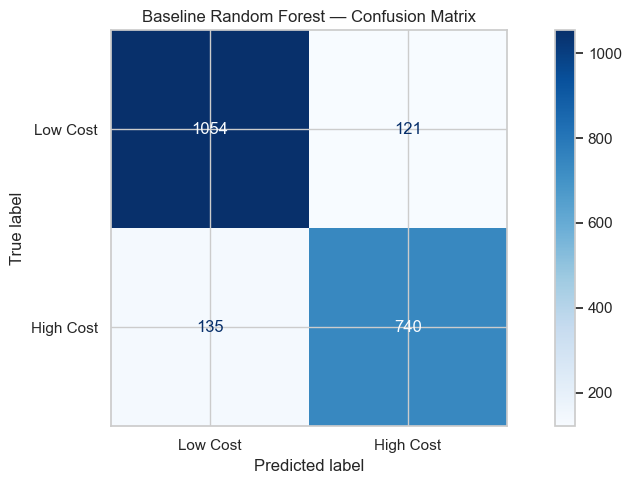

In [141]:

cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Low Cost', 'High Cost'])
disp.plot(cmap='Blues')
plt.title('Baseline Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

### Findings
The baseline Random Forest performs reasonably well. The confusion matrix shows how many High Cost cases the model correctly identified vs missed (false negatives) and how many Low Cost cases were incorrectly flagged (false positives). 



## 8. Hyperparameter Tuning — RandomizedSearchCV

We use RandomizedSearchCV instead of GridSearchCV because:
- GridSearchCV tests every single combination which can take long
- RandomizedSearchCV randomly samples combinations and finds results 
  much faster 
  — we test 50 random combinations across 5 folds = 250 model fits total



In [142]:
param_dist = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [None, 5, 10, 15, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', None],
    'bootstrap':         [True, False],
    'class_weight':      ['balanced', None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter              = 50,       
    scoring             = 'f1',     
    cv                  = cv,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1         
)

rf_search.fit(X_train_sm, y_train_sm)

print()
print('Best parameters found:')
for param, value in rf_search.best_params_.items():
    print(f'  {param}: {value}')
print()
print(f'Best CV F1 Score: {rf_search.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
  bootstrap: True
  class_weight: None
  max_depth: 15
  max_features: None
  min_samples_leaf: 4
  min_samples_split: 4
  n_estimators: 246

Best CV F1 Score: 0.8880


In [166]:
rf_tuned      = rf_search.best_estimator_
y_pred_tuned  = rf_tuned.predict(X_test)
y_proba_tuned = rf_tuned.predict_proba(X_test)[:, 1]

print('Tuned Random Forest Results')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_tuned):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_tuned):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_proba_tuned):.4f}')
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Low Cost', 'High Cost']))

Tuned Random Forest Results
Accuracy:  0.8898
Precision: 0.8795
Recall:    0.8594
F1 Score:  0.8694
AUC-ROC:   0.9655

              precision    recall  f1-score   support

    Low Cost       0.90      0.91      0.90      1175
   High Cost       0.88      0.86      0.87       875

    accuracy                           0.89      2050
   macro avg       0.89      0.89      0.89      2050
weighted avg       0.89      0.89      0.89      2050



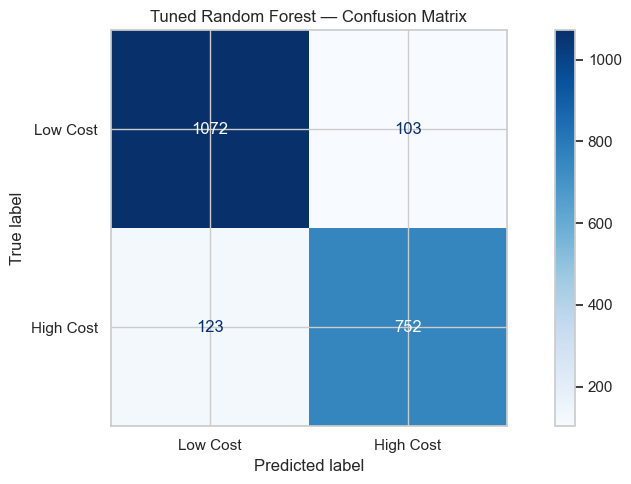

In [144]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned,
                                     display_labels=['Low Cost', 'High Cost'])
disp_tuned.plot(cmap='Blues')
plt.title('Tuned Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [145]:
results = pd.DataFrame({
    'Model':     ['Baseline RF', 'Tuned RF'],
    'Accuracy':  [accuracy_score(y_test, y_pred_base),  accuracy_score(y_test, y_pred_tuned)],
    'Precision': [precision_score(y_test, y_pred_base), precision_score(y_test, y_pred_tuned)],
    'Recall':    [recall_score(y_test, y_pred_base),    recall_score(y_test, y_pred_tuned)],
    'F1 Score':  [f1_score(y_test, y_pred_base),        f1_score(y_test, y_pred_tuned)],
    'AUC-ROC':   [roc_auc_score(y_test, y_proba_base),  roc_auc_score(y_test, y_proba_tuned)]
}).set_index('Model').round(4)

results

,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
Baseline RF,0.8751,0.8595,0.8457,0.8525,0.9546
Tuned RF,0.8898,0.8795,0.8594,0.8694,0.9655


### Findings
The tuned Random Forest performed a little better than the baseline one.

- **Accuracy** improved from 87.51% to 88.98%, meaning the tuned model correctly 
  classifies a higher proportion of observations overall
- **Precision** improved from 85.95% to 87.95%, meaning when the model predicts 
  High Cost it is more likely to be correct
- **Recall** improved from 84.57% to 85.94%, meaning the tuned model is better at 
  catching actual High Cost cases — reducing costly misses
- **F1 Score** improved from 0.8525 to 0.8694, reflecting a better overall balance 
  between precision and recall
- **AUC-ROC** improved

## 9. ROC Curve — Baseline vs Tuned Model



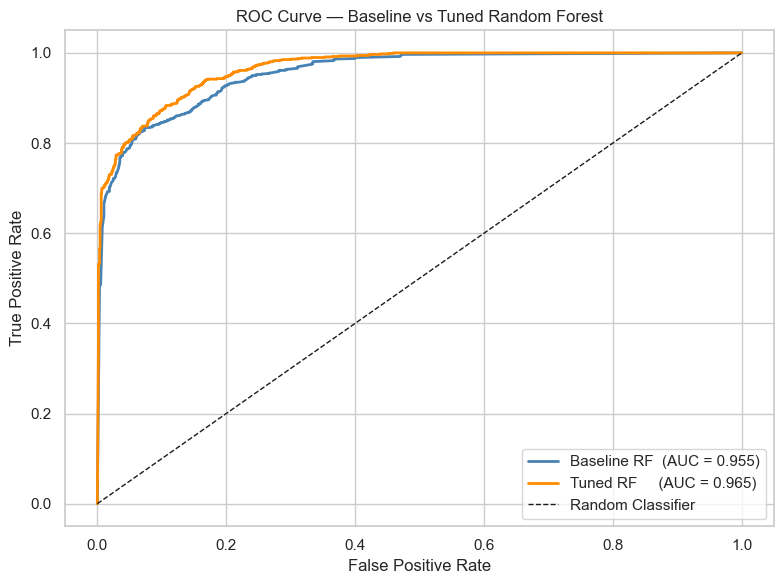

In [147]:
fpr_base,  tpr_base,  _ = roc_curve(y_test, y_proba_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)

auc_base  = roc_auc_score(y_test, y_proba_base)
auc_tuned = roc_auc_score(y_test, y_proba_tuned)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base,  tpr_base,  
         label=f'Baseline RF  (AUC = {auc_base:.3f})',  
         color='steelblue', lw=2)
plt.plot(fpr_tuned, tpr_tuned, 
         label=f'Tuned RF     (AUC = {auc_tuned:.3f})', 
         color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline vs Tuned Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Findings
Both models perform well above the random classifier baseline, meaning the Random Forest found genuine patterns in the data. The tuned model's ROC curve is slightly above the baseline. AUC-ROC score of 0.9655 vs 0.9546.

The high AUC-ROC means the model can be reliably used to rank regions by their affordability risk. Policymakers could use different 
classification thresholds depending on their risk tolerance. For example, lowering the threshold would flag more regions as High Cost, useful when the cost of missing a struggling region is high.

## 10. Feature Importance


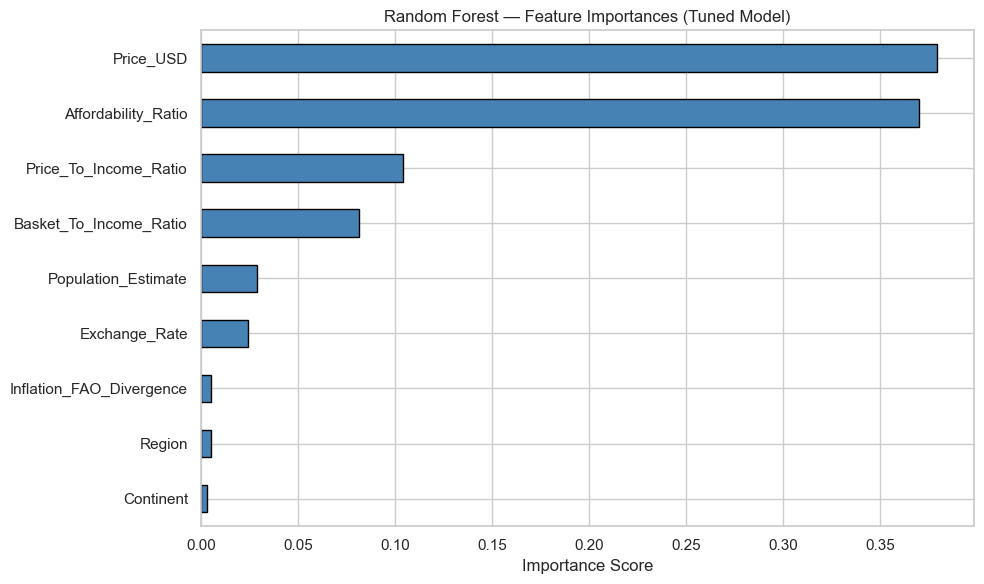

Feature Importances (ranked):
Price_USD                   0.3794
Affordability_Ratio         0.3698
Price_To_Income_Ratio       0.1038
Basket_To_Income_Ratio      0.0813
Population_Estimate         0.0287
Exchange_Rate               0.0239
Inflation_FAO_Divergence    0.0052
Region                      0.0049
Continent                   0.0031
dtype: float64


In [148]:
importances = pd.Series(rf_tuned.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Random Forest — Feature Importances (Tuned Model)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Feature Importances (ranked):')
print(importances.sort_values(ascending=False).round(4))

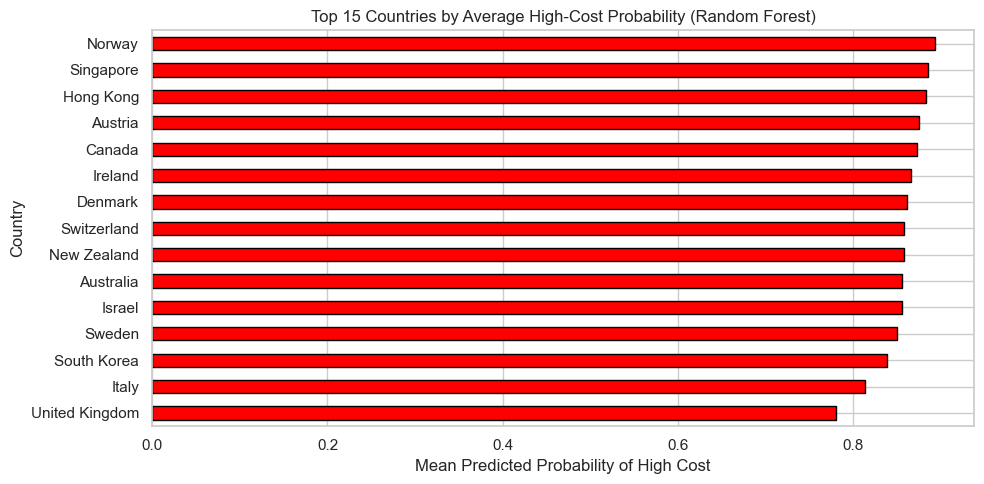

In [150]:
df['RF_Prediction']  = rf_tuned.predict(model_df[FEATURE_COLS])
df['RF_Probability'] = rf_tuned.predict_proba(model_df[FEATURE_COLS])[:, 1]

high_risk = (
    df.groupby('Country')['RF_Probability']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 5))
high_risk.plot(kind='barh', color='red', edgecolor='black')
plt.title('Top 15 Countries by Average High-Cost Probability (Random Forest)')
plt.xlabel('Mean Predicted Probability of High Cost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Findings
The feature importance chart ranks which factors the Random Forest had the most impact whenclassifying affordability risk. Price_USD and Price_To_Income_Ratio was highly ranked. This makes sense since the absolute price of groceries and how that price compares to local income are the direct measures of affordability stress.

The top 15 high risk countries chart shows which regions are consistently predicted as High Cost across all grocery items and months. 

## 11. Model Comparison Summary


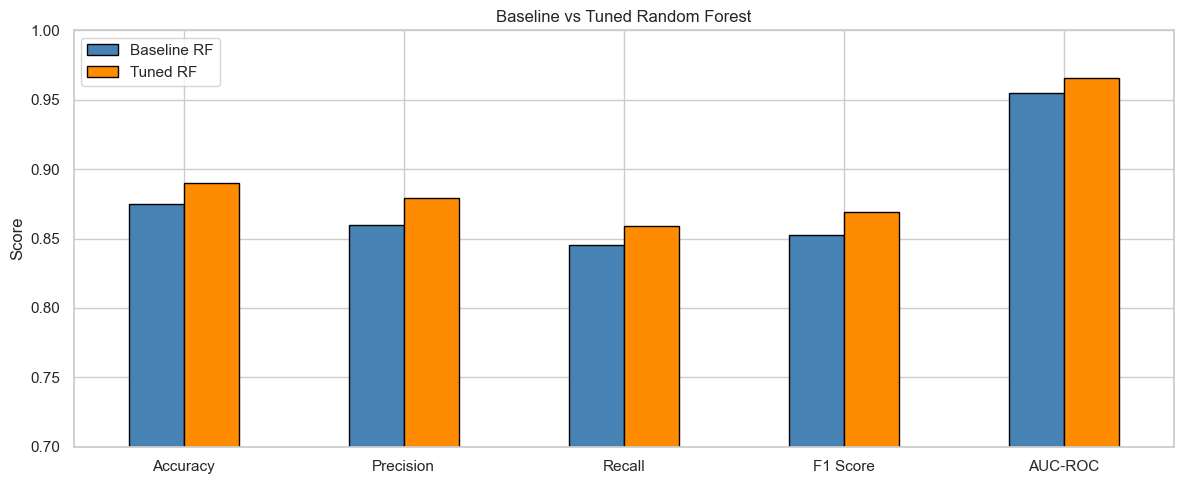

In [154]:
results.T.plot(kind='bar', figsize=(12, 5), color=['steelblue', 'darkorange'], 
               edgecolor='black')
plt.title('Baseline vs Tuned Random Forest')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.7, 1.0)
plt.legend(['Baseline RF', 'Tuned RF'])
plt.tight_layout()
plt.show()

### Findings 
The bar chart shows the improvement across all 5 metrics:
- orange bars (Tuned RF) 
- blue bars (Baseline RF)

Insights:
- **AUC-ROC of 0.9655**: the model can identify high cost cases 
- **F1 Score of 0.8694**: the model is good at both identifying High Cost regions and avoiding 
  false alarms
- **Recall of 0.8594**:the model correctly identifies 85.94% of genuinely High Cost regions


## 12. Business Insights


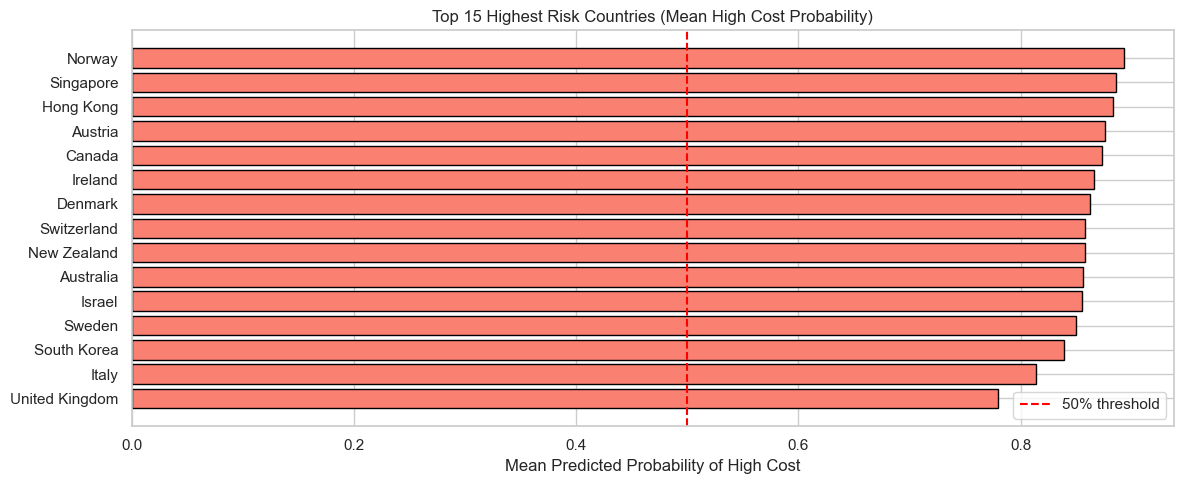

In [ ]:
# High risk countries
high_risk_full = (
    df.groupby(['Country', 'Continent'])['RF_Probability']
    .mean()
    .reset_index()
    .sort_values('RF_Probability', ascending=False)
)

# Top 15 
top_15 = high_risk_full.head(15)

plt.figure(figsize=(12, 5))
bars = plt.barh(top_15['Country'], top_15['RF_Probability'], 
                color='salmon', edgecolor='black')
plt.axvline(x=0.5, color='red', linestyle='--', label='50% threshold')
plt.title('Top 15 Highest Risk Countries (Mean High Cost Probability)')
plt.xlabel('Mean Predicted Probability of High Cost')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

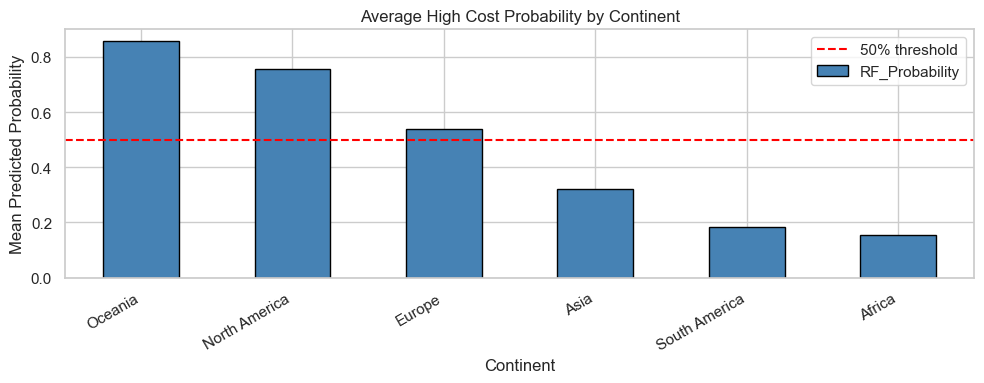

Average High Cost Probability by Continent:
Continent
Oceania          0.8565
North America    0.7573
Europe           0.5382
Asia             0.3204
South America    0.1819
Africa           0.1534
Name: RF_Probability, dtype: float64


In [158]:
# high cost probability by continent
continent_risk = (
    df.groupby('Continent')['RF_Probability']
    .mean()
    .sort_values(ascending=False)
    .round(4)
)

plt.figure(figsize=(10, 4))
continent_risk.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average High Cost Probability by Continent')
plt.ylabel('Mean Predicted Probability')
plt.xticks(rotation=30, ha='right')
plt.axhline(y=0.5, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

print('Average High Cost Probability by Continent:')
print(continent_risk)

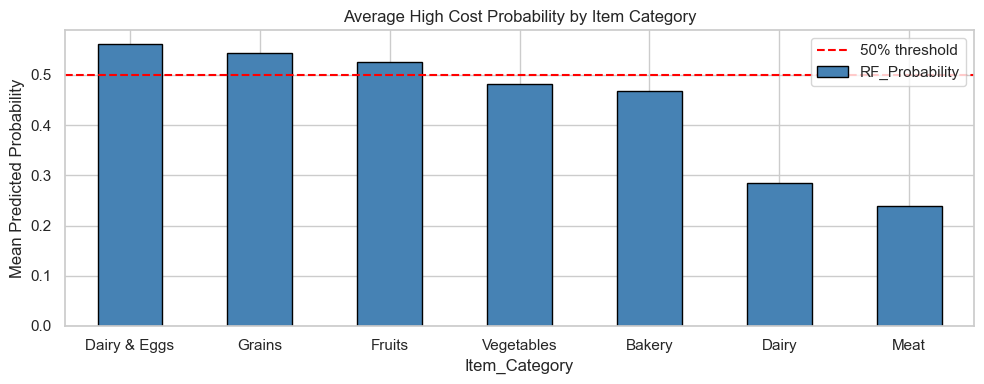

Average High Cost Probability by Item Category:
Item_Category
Dairy & Eggs    0.5606
Grains          0.5430
Fruits          0.5262
Vegetables      0.4827
Bakery          0.4674
Dairy           0.2845
Meat            0.2387
Name: RF_Probability, dtype: float64


In [159]:
# High cost rate by grocery item 
item_risk = (
    df.groupby('Item_Category')['RF_Probability']
    .mean()
    .sort_values(ascending=False)
    .round(4)
)

plt.figure(figsize=(10, 4))
item_risk.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average High Cost Probability by Item Category')
plt.ylabel('Mean Predicted Probability')
plt.xticks(rotation=0)
plt.axhline(y=0.5, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

print('Average High Cost Probability by Item Category:')
print(item_risk)

## 13. Save Model Output


In [161]:
import joblib

joblib.dump(rf_tuned, 'rf_tuned_model.pkl')

output_cols = ['Country', 'Continent', 'Region', 'Month', 
               'Item', 'Item_Category', 'Price_USD',
               'Wage_Adjusted_High_Cost', 'RF_Prediction', 'RF_Probability']
df[output_cols].to_csv('rf_predictions.csv', index=False)


print()


In [164]:


print('RANDOM FOREST MODEL — FINAL SUMMARY')

print()
print(f'Dataset:         {df.shape[0]:,} observations, {len(FEATURE_COLS)} features')
print(f'Training set:    {X_train_sm.shape[0]:,} samples (after SMOTE)')
print(f'Test set:        {X_test.shape[0]:,} samples')
print()
print('Tuned Model Performance:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred_tuned):.4f}')
print(f'  F1 Score:  {f1_score(y_test, y_pred_tuned):.4f}')
print(f'  AUC-ROC:   {roc_auc_score(y_test, y_proba_tuned):.4f}')
print()
print('Best Parameters:')
for param, value in rf_search.best_params_.items():
    print(f'  {param}: {value}')
print()



RANDOM FOREST MODEL — FINAL SUMMARY

Dataset:         10,248 observations, 9 features
Training set:    9,402 samples (after SMOTE)
Test set:        2,050 samples

Tuned Model Performance:
  Accuracy:  0.8898
  Precision: 0.8795
  Recall:    0.8594
  F1 Score:  0.8694
  AUC-ROC:   0.9655

Best Parameters:
  bootstrap: True
  class_weight: None
  max_depth: 15
  max_features: None
  min_samples_leaf: 4
  min_samples_split: 4
  n_estimators: 246

